# EDA: Time-Aware Trending Products

Exploratory Data Analysis of the Instacart dataset to understand contextual shopping patterns.

**Goal**: Analyze how product purchasing behavior varies by:
- Day of week (`order_dow`)
- Hour of day (`order_hour_of_day`)
- Time bucket (Morning / Afternoon / Night)
- Reorder patterns
- Department and aisle trends

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('dark_background')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

DATA_PATH = '../data/combined_instacart_data.csv'

## 1. Load Dataset

In [3]:
# Read with optimized dtypes
dtype_map = {
    'order_id': 'int32', 'product_id': 'int32',
    'reordered': 'int8', 'order_dow': 'int8',
    'order_hour_of_day': 'int8', 'user_id': 'int32',
}

use_cols = ['order_id', 'product_id', 'reordered', 'order_dow',
            'order_hour_of_day', 'product_name', 'aisle', 'department']

df = pd.read_csv(DATA_PATH, usecols=use_cols,
                 dtype={k: v for k, v in dtype_map.items() if k in use_cols})

print(f'Shape: {df.shape}')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
df.head()

Shape: (33819106, 8)
Memory: 2.79 GB


,order_id,product_id,reordered,order_dow,order_hour_of_day,product_name,aisle,department
0,2,33120,1,5,9,Organic Egg Whites,eggs,dairy eggs
1,2,28985,1,5,9,Michigan Organic Kale,fresh vegetables,produce
2,2,9327,0,5,9,Garlic Powder,spices seasonings,pantry
3,2,45918,1,5,9,Coconut Butter,oils vinegars,pantry
4,2,30035,0,5,9,Natural Sweetener,baking ingredients,pantry


## 2. Add Time Buckets

In [4]:
# Time bucket mapping: 3 buckets
def get_time_bucket(hour):
    if 5 <= hour <= 11:
        return 'morning'
    elif 12 <= hour <= 17:
        return 'afternoon'
    else:
        return 'night'

df['time_bucket'] = df['order_hour_of_day'].map({h: get_time_bucket(h) for h in range(24)})

# Day names (Instacart: 0=Saturday)
DAY_NAMES = {0: 'Saturday', 1: 'Sunday', 2: 'Monday', 3: 'Tuesday',
             4: 'Wednesday', 5: 'Thursday', 6: 'Friday'}
df['day_name'] = df['order_dow'].map(DAY_NAMES)

print('Time bucket distribution:')
print(df['time_bucket'].value_counts())
print(f'\nDay distribution:')
print(df['day_name'].value_counts())

Time bucket distribution:
time_bucket
afternoon    15936406
morning      11388324
night         6494376
Name: count, dtype: int64

Day distribution:
day_name
Saturday     6533692
Sunday       5871834
Friday       4707583
Thursday     4386443
Monday       4378360
Tuesday      3998498
Wednesday    3942696
Name: count, dtype: int64


## 3. Order Volume by Day x Time

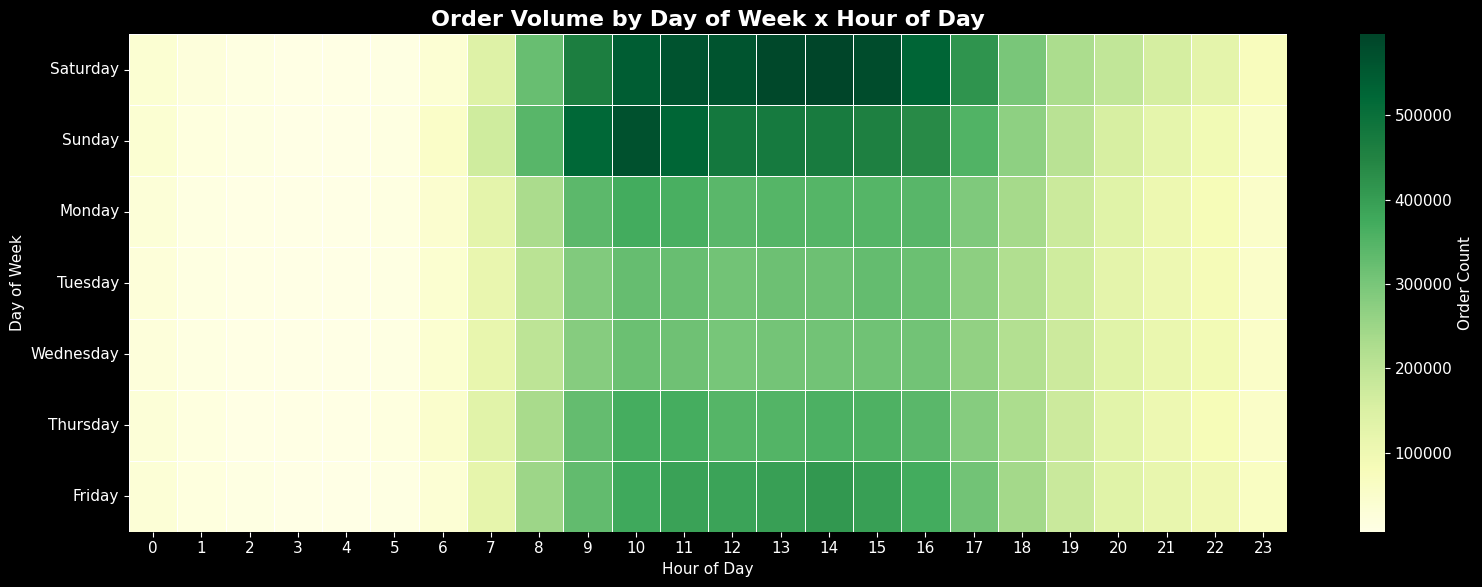

In [5]:
# Heatmap: orders by day x hour
heatmap_data = df.groupby(['order_dow', 'order_hour_of_day']).size().unstack(fill_value=0)
heatmap_data.index = [DAY_NAMES[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data, cmap='YlGn', annot=False, fmt='d',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Order Count'})
ax.set_title('Order Volume by Day of Week x Hour of Day', fontsize=16, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

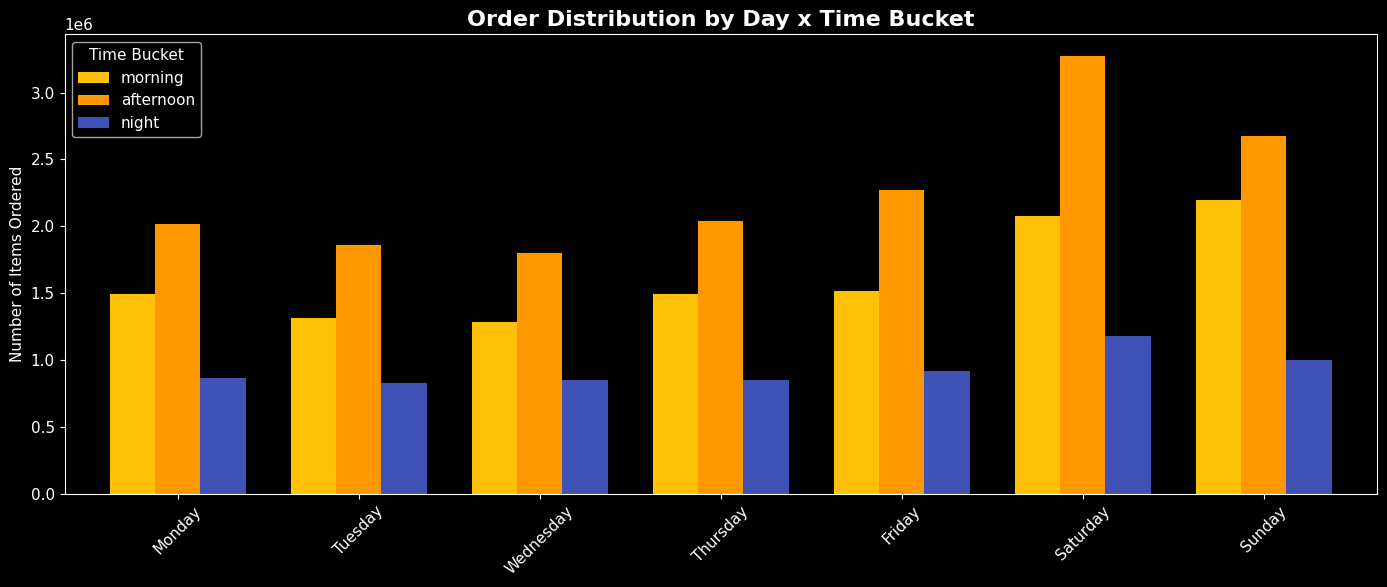

In [6]:
# Bar chart: orders by time bucket per day
bucket_day = df.groupby(['day_name', 'time_bucket']).size().reset_index(name='count')
bucket_order = ['morning', 'afternoon', 'night']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(14, 6))
pivot = bucket_day.pivot(index='day_name', columns='time_bucket', values='count').reindex(day_order)[bucket_order]
pivot.plot(kind='bar', ax=ax, width=0.75, color=['#FFC107', '#FF9800', '#3F51B5'])
ax.set_title('Order Distribution by Day x Time Bucket', fontsize=16, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Items Ordered')
ax.legend(title='Time Bucket')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 4. Reorder Analysis

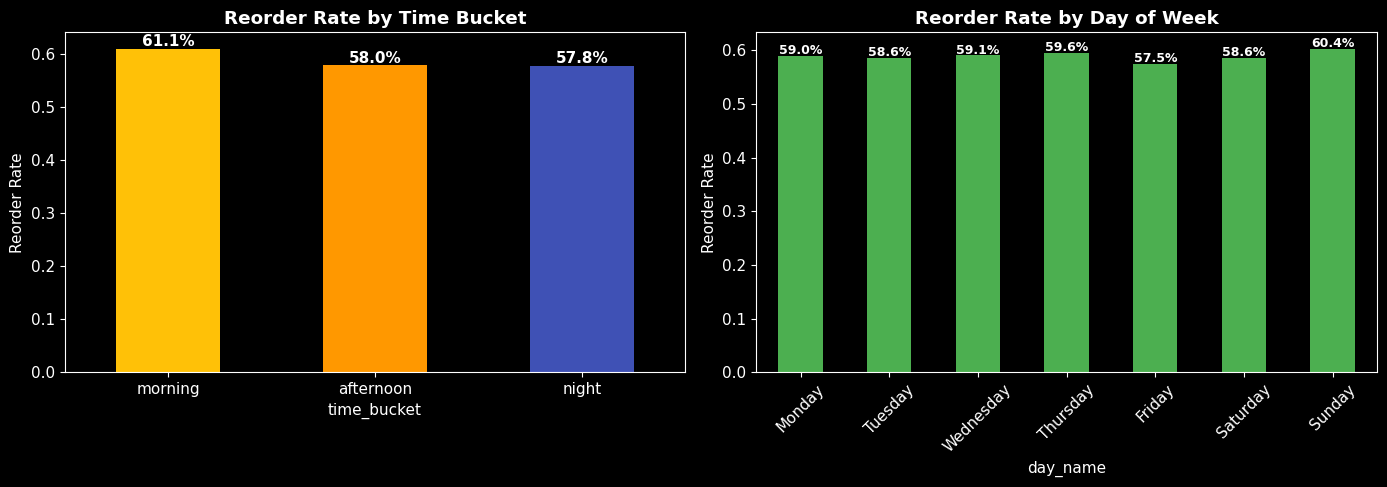

In [7]:
# Reorder rate by time bucket
reorder_by_bucket = df.groupby('time_bucket')['reordered'].mean().reindex(bucket_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By time bucket
reorder_by_bucket.plot(kind='bar', ax=axes[0], color=['#FFC107', '#FF9800', '#3F51B5'])
axes[0].set_title('Reorder Rate by Time Bucket', fontweight='bold')
axes[0].set_ylabel('Reorder Rate')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(reorder_by_bucket):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')

# By day
reorder_by_day = df.groupby('day_name')['reordered'].mean().reindex(day_order)
reorder_by_day.plot(kind='bar', ax=axes[1], color='#4CAF50')
axes[1].set_title('Reorder Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Reorder Rate')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(reorder_by_day):
    axes[1].text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

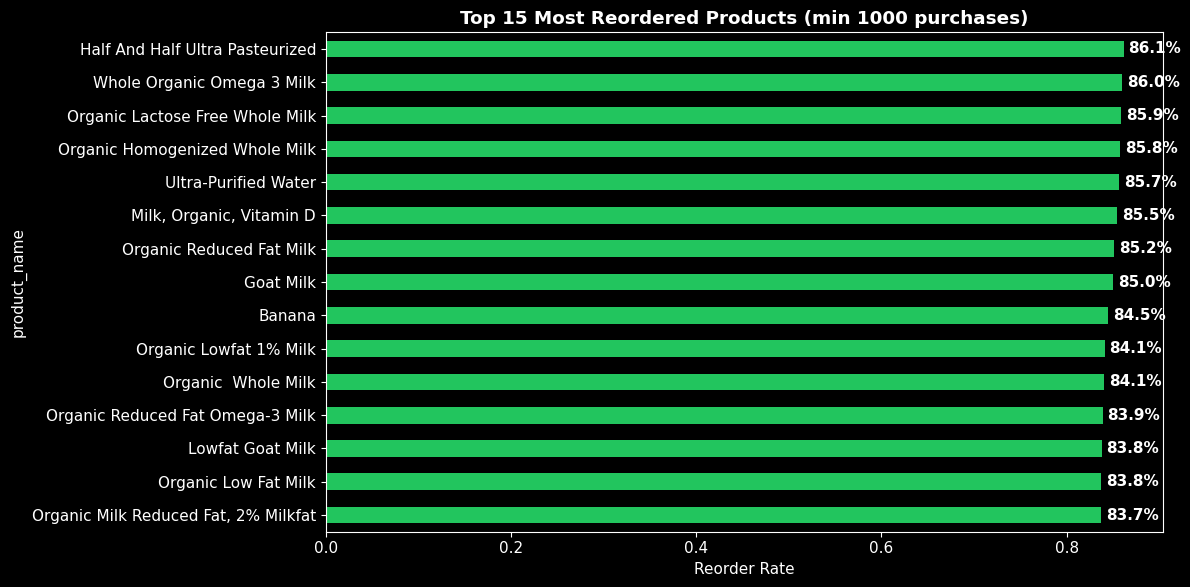

In [8]:
# Top 15 most reordered products
product_reorder = (
    df.groupby('product_name')
    .agg(total=('reordered', 'size'), reorders=('reordered', 'sum'))
    .query('total >= 1000')  # min 1000 purchases
    .assign(reorder_rate=lambda x: x['reorders'] / x['total'])
    .nlargest(15, 'reorder_rate')
)

fig, ax = plt.subplots(figsize=(12, 6))
product_reorder['reorder_rate'].plot(kind='barh', ax=ax, color='#22c55e')
ax.set_title('Top 15 Most Reordered Products (min 1000 purchases)', fontweight='bold')
ax.set_xlabel('Reorder Rate')
ax.invert_yaxis()
for i, v in enumerate(product_reorder['reorder_rate']):
    ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Department Trends by Time

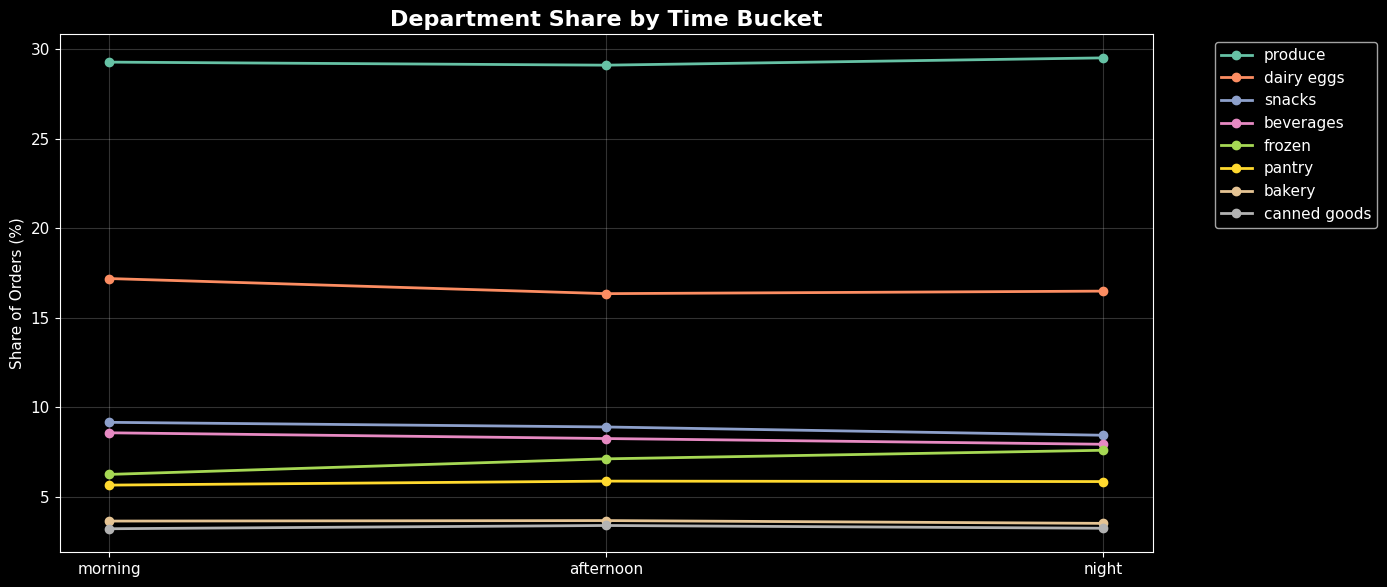

In [9]:
# Department share by time bucket
dept_time = (
    df.groupby(['time_bucket', 'department']).size()
    .reset_index(name='count')
)
dept_time['share'] = dept_time.groupby('time_bucket')['count'].transform(lambda x: x / x.sum())

# Top 8 departments
top_depts = df['department'].value_counts().head(8).index.tolist()

fig, ax = plt.subplots(figsize=(14, 6))
for dept in top_depts:
    dept_data = dept_time[dept_time['department'] == dept].set_index('time_bucket').reindex(bucket_order)
    ax.plot(dept_data.index, dept_data['share'] * 100, marker='o', linewidth=2, label=dept)

ax.set_title('Department Share by Time Bucket', fontsize=16, fontweight='bold')
ax.set_ylabel('Share of Orders (%)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

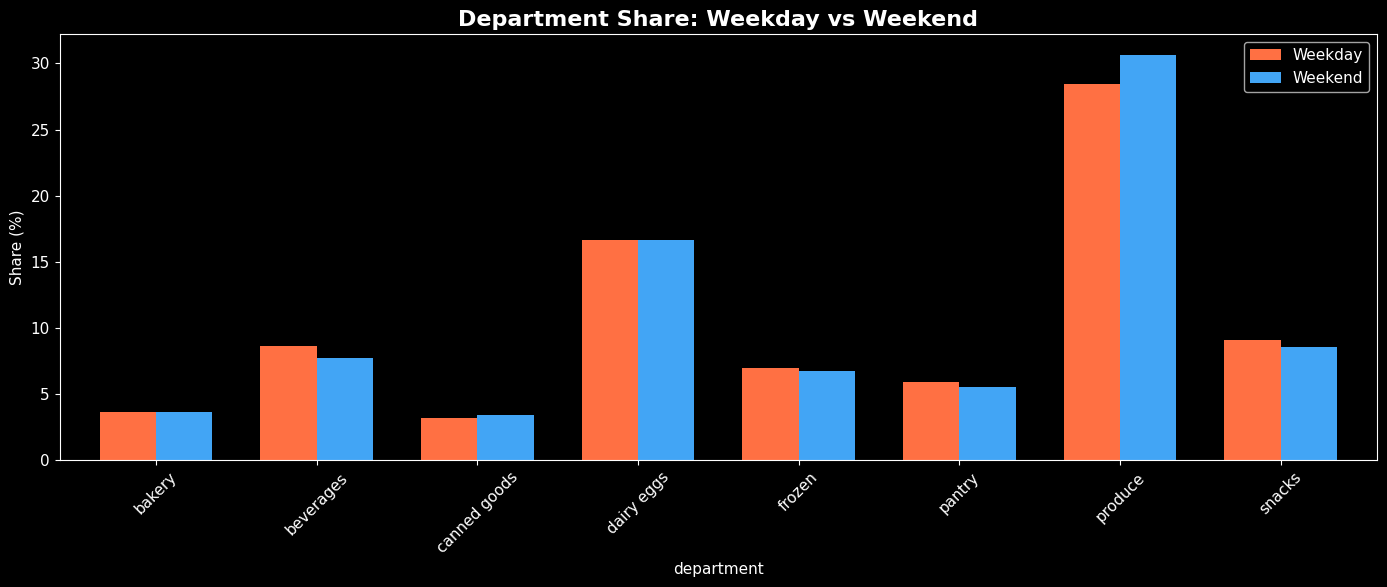

In [10]:
# Weekday vs Weekend comparison
df['is_weekend'] = df['order_dow'].isin([0, 1])  # Sat, Sun

weekend_dept = (
    df.groupby(['is_weekend', 'department']).size()
    .reset_index(name='count')
    .assign(label=lambda x: x['is_weekend'].map({True: 'Weekend', False: 'Weekday'}))
)
weekend_dept['share'] = weekend_dept.groupby('label')['count'].transform(lambda x: x / x.sum())

fig, ax = plt.subplots(figsize=(14, 6))
pivot_wd = weekend_dept[weekend_dept['department'].isin(top_depts)].pivot(
    index='department', columns='label', values='share'
) * 100
pivot_wd.plot(kind='bar', ax=ax, color=['#FF7043', '#42A5F5'], width=0.7)
ax.set_title('Department Share: Weekday vs Weekend', fontsize=16, fontweight='bold')
ax.set_ylabel('Share (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Top Products by Context

In [11]:
# Top 10 products per time bucket
for bucket in bucket_order:
    subset = df[df['time_bucket'] == bucket]
    top = subset['product_name'].value_counts().head(10)
    print(f'\n=== Top 10 Products: {bucket.upper()} ===')
    for i, (name, count) in enumerate(top.items(), 1):
        print(f'  {i}. {name} ({count:,} purchases)')


=== Top 10 Products: MORNING ===
  1. Banana (171,333 purchases)
  2. Bag of Organic Bananas (136,484 purchases)
  3. Organic Strawberries (93,268 purchases)
  4. Organic Baby Spinach (83,287 purchases)
  5. Organic Hass Avocado (73,162 purchases)
  6. Organic Avocado (60,023 purchases)
  7. Large Lemon (53,927 purchases)
  8. Strawberries (52,622 purchases)
  9. Organic Raspberries (50,156 purchases)
  10. Organic Whole Milk (50,132 purchases)

=== Top 10 Products: AFTERNOON ===
  1. Banana (225,959 purchases)
  2. Bag of Organic Bananas (181,869 purchases)
  3. Organic Strawberries (126,982 purchases)
  4. Organic Baby Spinach (118,684 purchases)
  5. Organic Hass Avocado (104,959 purchases)
  6. Organic Avocado (88,731 purchases)
  7. Large Lemon (77,885 purchases)
  8. Limes (72,004 purchases)
  9. Strawberries (68,325 purchases)
  10. Organic Raspberries (64,447 purchases)

=== Top 10 Products: NIGHT ===
  1. Banana (93,999 purchases)
  2. Bag of Organic Bananas (76,577 purchases

In [12]:
# Products with highest contextual variance (most time-sensitive)
product_by_bucket = (
    df.groupby(['product_name', 'time_bucket']).size()
    .reset_index(name='count')
    .pivot(index='product_name', columns='time_bucket', values='count')
    .fillna(0)
)

# Coefficient of variation across time buckets
product_by_bucket['cv'] = product_by_bucket[bucket_order].std(axis=1) / product_by_bucket[bucket_order].mean(axis=1)
product_by_bucket['total'] = product_by_bucket[bucket_order].sum(axis=1)

# Filter to popular products (>5000 purchases) with high variance
time_sensitive = product_by_bucket[product_by_bucket['total'] > 5000].nlargest(15, 'cv')
print('Products Most Sensitive to Time of Day:')
print(time_sensitive[bucket_order + ['cv']].to_string())

Products Most Sensitive to Time of Day:
time_bucket                         morning  afternoon   night        cv
product_name                                                            
Trail Mix                            6423.0     5362.0   816.0  0.709120
Zero Calorie Cola                    4273.0     3942.0   690.0  0.667049
Original Beef Jerky                  3271.0     2885.0   541.0  0.661818
Milk Chocolate Almonds               2530.0     2321.0   427.0  0.658520
Sauvignon Blanc                      2383.0     4909.0  1249.0  0.658096
Crunchy Oats 'n Honey Granola Bars   4504.0     3801.0   777.0  0.654137
Apples                               6576.0     5120.0  1187.0  0.649173
Popcorn                              3452.0     3030.0   620.0  0.645399
Extra Fancy Unsalted Mixed Nuts      4824.0     4331.0   875.0  0.643611
Chardonnay                           1734.0     3622.0   990.0  0.641414
Cabernet Sauvignon                   1629.0     3641.0  1082.0  0.636452
0% Greek St

## 7. Summary Statistics

In [13]:
print('=== Dataset Summary ===')
print(f'Total records: {len(df):,}')
print(f'Unique products: {df["product_name"].nunique():,}')
print(f'Unique departments: {df["department"].nunique()}')
print(f'Unique aisles: {df["aisle"].nunique()}')
print(f'Overall reorder rate: {df["reordered"].mean():.1%}')
print(f'\nOrders by time bucket:')
for bucket in bucket_order:
    count = (df['time_bucket'] == bucket).sum()
    pct = count / len(df) * 100
    print(f'  {bucket:12s}: {count:>12,} ({pct:.1f}%)')

=== Dataset Summary ===
Total records: 33,819,106
Unique products: 49,685
Unique departments: 21
Unique aisles: 134
Overall reorder rate: 59.0%

Orders by time bucket:
  morning     :   11,388,324 (33.7%)
  afternoon   :   15,936,406 (47.1%)
  night       :    6,494,376 (19.2%)
